I've gotten a dataset that I want to try Machine Learning on what do I do now?
# Clean the data !!!!
1. What is in the dataset
 2. What are the data types
 3. Remove incomplete or blank rows -> impute 
 4. Granularity of each observation 

 # Machine Learning
1. What is the goal of this dataset ->  Purchase predictions
2. Supervised Learning
3. Process the variables ->  Dummies for categorical variables -> One hot Encoding
4. Scale all numerical features -> -1 - 1 with a standard devation of one

In [17]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('Data.csv')
df.head()


,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9.0,38.777778,7.693793,27.0,35.0,38.0,44.0,50.0
Salary,9.0,63777.777778,12265.579662,48000.0,54000.0,61000.0,72000.0,83000.0


In [5]:
df['Country'].value_counts(dropna=False)

Country
France     4
Spain      3
Germany    3
Name: count, dtype: int64

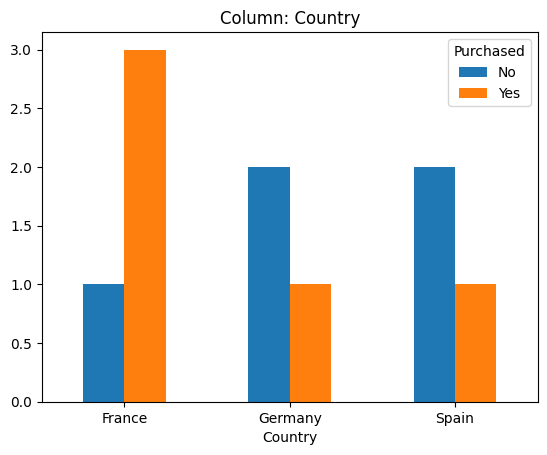

In [6]:
import matplotlib.pyplot as plt
df.groupby(['Country'])['Purchased'].value_counts().unstack().plot(kind='bar', stacked=False, rot=0)
plt.title('Column: Country')
plt.show()

In [7]:
# Missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df.iloc[:, 1:3] = imputer.fit_transform(df.iloc[:, 1:3])
df.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.000000,No
1,Spain,27.0,48000.000000,Yes
2,Germany,30.0,54000.000000,No
3,Spain,38.0,61000.000000,No
4,Germany,40.0,63777.777778,Yes


In [22]:
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
temp = df.copy()
temp.iloc[:, 3] = label_encoder.fit_transform(df.iloc[:, 3])
temp.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.000000,0
1,Spain,27.0,48000.000000,1
2,Germany,30.0,54000.000000,0
3,Spain,38.0,61000.000000,0
4,Germany,40.0,63777.777778,1


In [9]:
# Encode categorical data
pd.get_dummies(df.iloc[:, :-1])

,Age,Salary,Country_France,Country_Germany,Country_Spain
0,44.000000,72000.000000,True,False,False
1,27.000000,48000.000000,False,False,True
2,30.000000,54000.000000,False,True,False
3,38.000000,61000.000000,False,False,True
4,40.000000,63777.777778,False,True,False
5,35.000000,58000.000000,True,False,False
6,38.777778,52000.000000,False,False,True
7,48.000000,79000.000000,True,False,False
8,50.000000,83000.000000,False,True,False
9,37.000000,67000.000000,True,False,False


In [10]:
# Encode categorical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

data = df.drop(['Purchased'], axis=1, inplace=False)
categorical_features = data.select_dtypes(include='object').columns
t = [('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)]
col_transform = ColumnTransformer(transformers=t)
col_transform.set_output(transform="pandas")
encoded_data = col_transform.fit_transform(data)
encoded_data.head()

,encoder__Country_Germany,encoder__Country_Spain
0,0.0,0.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0


In [11]:
# Joining tables
concat_data = pd.concat([data, encoded_data], axis=1)
# Dropping old categorical columns
concat_data.drop(categorical_features, axis=1, inplace=True)
# Checking result
concat_data.head()

,Age,Salary,encoder__Country_Germany,encoder__Country_Spain
0,44.0,72000.000000,0.0,0.0
1,27.0,48000.000000,0.0,1.0
2,30.0,54000.000000,1.0,0.0
3,38.0,61000.000000,0.0,1.0
4,40.0,63777.777778,1.0,0.0


In [12]:
from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler

standard_scaler = StandardScaler()
normalizer = Normalizer()
min_max_scaler = MinMaxScaler()

print("Standardization")
print(standard_scaler.fit_transform(temp.iloc[:, 1:3]))

Standardization
[[ 7.58874362e-01  7.49473254e-01]
 [-1.71150388e+00 -1.43817841e+00]
 [-1.27555478e+00 -8.91265492e-01]
 [-1.13023841e-01 -2.53200424e-01]
 [ 1.77608893e-01  6.63219199e-16]
 [-5.48972942e-01 -5.26656882e-01]
 [ 0.00000000e+00 -1.07356980e+00]
 [ 1.34013983e+00  1.38753832e+00]
 [ 1.63077256e+00  1.75214693e+00]
 [-2.58340208e-01  2.93712492e-01]]


In [13]:
df = pd.read_csv('Data.csv').dropna()
df.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
5,France,35.0,58000.0,Yes


In [25]:
X = df[["Age", "Salary"]].dropna().values.astype(np.float64)
X_scale=standard_scaler.fit_transform(X)

In [30]:
X_scale.std(axis=0)

array([1., 1.])

In [34]:
(X - np.mean(X,axis=0))/X.std(axis=0)

array([[ 0.69985807,  0.58989097],
       [-1.51364653, -1.50749915],
       [-1.12302807, -0.98315162],
       [-0.08137885, -0.37141284],
       [-0.47199731, -0.6335866 ],
       [ 1.22068269,  1.20162976],
       [ 1.48109499,  1.55119478],
       [-0.211585  ,  0.1529347 ]])

np.float64(0.4218239668325841)